In [15]:
import matplotlib.pyplot as plt
import numpy as np

import hobj

In [16]:
# Load benchmarks
from hobj import MutatorHighVarBenchmark, MutatorOneshotBenchmark

benchmark1 = MutatorHighVarBenchmark()
benchmark2 = MutatorOneshotBenchmark()

# Benchmark a learning model

In [17]:
# Loading the exmaple precomputed image features. You can replace this with your own features!
data = np.load('/examples/example_features.npz') # ResNet50/avgpool features, randomly downprojected to 100 dimensions
features = data['features'] # N x 100 feature matrix
image_ids = data['image_ids'] # N image ids
image_id_to_features = {image_id:f for (image_id, f) in zip(features, image_ids)}



In [19]:
learner = hobj.create_linear_learner(
    image_id_to_features=image_id_to_features,
    update_rule_name='Square',
    alpha=1,
)

# Alternatively, you can use a random guesser as a baseline:
# learner = hobj.RandomGuesser()

## Experiment 1 benchmark

In [21]:
# Benchmark on Experiment 1
result1 = benchmark1(learner=learner, show_pbar=True)
result1

LearningCurveBenchmark.LearningCurveBenchmarkResult(msen=0.0055746894992691285, msen_sigma=0.00028657494694110414, msen_CI95=(0.004977290624735935, 0.006121000076948812), lapse_rate=<xarray.DataArray 'phat' ()> Size: 8B
array(0.07861494), model_statistics=<xarray.LearningCurveStatistics> Size: 103MB
Dimensions:           (subtask: 64, trial: 100, boot_iter: 1000)
Coordinates:
  * subtask           (subtask) <U33 8kB 'MutatorObject000,MutatorObject095' ...
Dimensions without coordinates: trial, boot_iter
Data variables:
    phat              (subtask, trial) float64 51kB 0.51 0.732 ... 0.91 0.888
    varhat_phat       (subtask, trial) float64 51kB 0.0005008 ... 0.0001993
    boot_phat         (boot_iter, subtask, trial) float64 51MB 0.526 ... 0.874
    boot_varhat_phat  (boot_iter, subtask, trial) float64 51MB 0.0004996 ... ...)

MSEn 95% confidence interval: [0.005, 0.006]


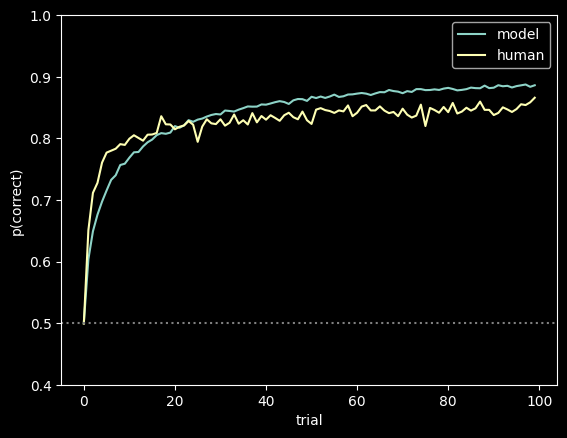

In [22]:
# Plot model behavior
print(f"MSEn 95% confidence interval: [{result1.msen_CI95[0]:.3f}, {result1.msen_CI95[1]:.3f}]")
plt.plot(result1.model_statistics.phat.mean('subtask'), label = 'model')
plt.plot(benchmark1.target_statistics.phat.mean('subtask'), label = 'human')
plt.ylim([0.4, 1])
plt.axhline(0.5, ls = ':', color = 'gray')
plt.legend()
plt.xlabel('trial')
plt.ylabel('p(correct)')
plt.show()


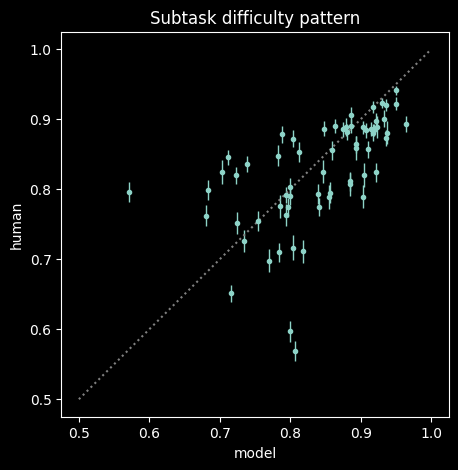

In [34]:
plt.figure(figsize = (5, 5))
plt.errorbar(
    result1.model_statistics.phat.mean('trial'),
    benchmark1.target_statistics.phat.mean('trial'),
    xerr=result1.model_statistics.boot_phat.mean('trial').std(dim='boot_iter', ddof=1),
    yerr=benchmark1.target_statistics.boot_phat.mean('trial').std(dim='boot_iter', ddof=1),
    marker='.',
    lw =0,
    elinewidth=1
)
plt.xlabel('model')
plt.ylabel('human')
plt.title('Subtask difficulty pattern')
plt.plot([0.5, 1], [0.5, 1], ls = ':', color = 'gray')
plt.show()


## Experiment 2 benchmark

In [23]:
result2 = benchmark2(learner = learner)
result2

GeneralizationBenchmark.GeneralizationBenchmarkResult(msen=0.01929741563254476, msen_sigma=0.0024513021659298712, msen_CI95=(0.014086503611026608, 0.023757523049323704), model_statistics=<xarray.GeneralizationStatistics> Size: 583kB
Dimensions:               (transformation: 36, boot_iter: 1000)
Coordinates:
  * transformation        (transformation) <U26 4kB 'backgrounds | 0.1' ... '...
    transformation_type   (transformation) <U18 3kB 'backgrounds' ... 'scale'
    transformation_level  (transformation) float64 288B 0.1 0.2154 ... 0.5 1.5
Dimensions without coordinates: boot_iter
Data variables:
    phat                  (transformation) float64 288B 0.9748 0.9752 ... 0.9491
    varhat_phat           (transformation) float64 288B 5.711e-06 ... 2.237e-05
    boot_phat             (boot_iter, transformation) float64 288kB 0.9735 .....
    boot_varhat_phat      (boot_iter, transformation) float64 288kB 6.032e-06...)

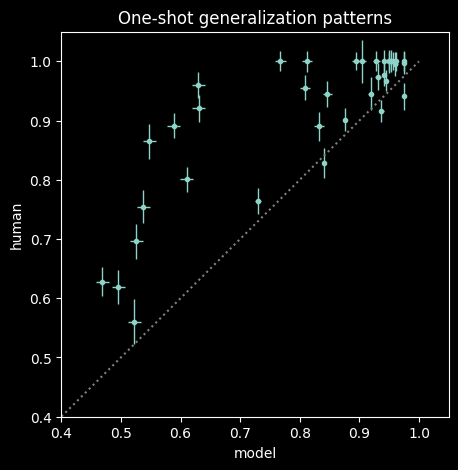

In [24]:
plt.figure(figsize = (5, 5))
x = result2.model_statistics.phat 
xerr = np.sqrt(result2.model_statistics.varhat_phat)

y = benchmark2.target_statistics.phat 
yerr = np.sqrt(benchmark2.target_statistics.varhat_phat)
plt.errorbar(x, y, xerr=xerr, yerr = yerr, lw = 0, elinewidth=1, marker = '.')
plt.plot([0, 1], [0, 1], ls = ':', color = 'gray')
plt.axis([0.4, 1.05, 0.4, 1.05])
plt.xlabel('model')
plt.ylabel('human')
plt.title('One-shot generalization patterns')
plt.show()